In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import glob
import numpy as np

In [2]:
def plot_camd_density(df, varx='bp_rp', vary='MG_noext',
                      xlabel='$G_{BP} - G_{RP}$', ylabel='$M_G$'):
    """

    #plot the color absolute magnitude diagram (density plot)
    Parameters
    ----------
    df : pandas df
        Data to plot.
    varx : str, optional
        x-axis variable to plot. The default is 'bp_rp'.
    vary : str, optional
        y-axis variable to plot. The default is 'MG_noext'.
    xlabel : str, optional
        x-axis label. The default is '$G_{BP} - G_{RP}$'.
    ylabel : str, optional
        y-axis label. The default is '$M_G$'.

    Returns
    -------
    None.

    """

    plt.rc('text', usetex=True)
    bp_rp = df[varx].to_list()
    mg = df[vary].to_list()

    fig, ax = plt.subplots(figsize=(8, 8))
    figt = '$N_{stars}$='+'{}'.format(len(df))
    fig.suptitle(r'{}'.format(figt))
    # only show 2D-histogram for bins with more than 10 stars in them
    h = ax.hist2d(bp_rp, mg, bins=300, cmin=1, norm=colors.PowerNorm(
        0.5), zorder=0.5, cmap=plt.cm.hot)
    # fill the rest with scatter (set rasterized=True if saving as vector graphics)
    ax.scatter(bp_rp, mg, alpha=0.9, s=1, color='k', zorder=0)
    ax.invert_yaxis()
    cb = fig.colorbar(h[3], ax=ax, pad=0.02)
    ax.set_xlabel(r'{}'.format(xlabel))
    ax.set_ylabel(r'{}'.format(ylabel))
    cb.set_label(r"$\mathrm{Stellar~density}$")
    ax.grid(visible=True)

In [3]:
def load_cat(dataDir,cat):
    fis = glob.glob('{}/{}/*.hdf5'.format(dataDir,cat))
    data = pd.DataFrame()
    for fi in fis:
        d = pd.read_hdf(fi)
        data = pd.concat((data,d))
    data.columns
    return data

In [4]:
dataDir = '/home/philippe/LSST/gaia_files/gaiadr3'

            bp_rp        MG
58       0.646277  1.002869
141      0.872395  0.951840
167      0.558614  2.684788
461      0.840554  2.331870
572      2.471571  2.699652
...           ...       ...
2162191  0.664504  1.559448
2162230  0.586754  2.370123
2162432  0.184739  0.417888
2162609  0.474946  1.900066
2162759  0.139544  1.420561

[1566953 rows x 2 columns]
Index(['source_id', 'ra', 'dec', 'pmra', 'pmdec', 'parallax', 'parallax_error',
       'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'l', 'b',
       'phot_variable_flag', 'ref_epoch', 'L', 'B', 'ag_gspphot', 'MG',
       'bp_rp', 'MG_noext'],
      dtype='object')


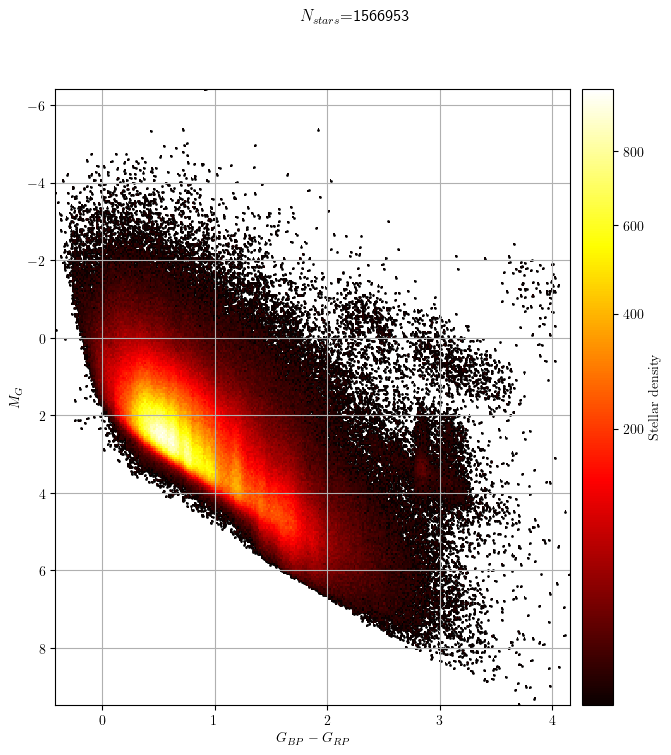

In [5]:
cat = 'gold_sample_oba_gaia_source'
df_source = load_cat(dataDir,cat)
df_source['bp_rp'] = df_source['phot_bp_mean_mag']-df_source['phot_rp_mean_mag']
df_source['MG_noext'] = df_source['phot_g_mean_mag'] + 5-5*np.log10(1.e3/df_source['parallax'])
df_source = df_source.dropna()
print(df_source[['bp_rp','MG']])
print(df_source.columns)
plot_camd_density(df_source)

In [6]:
cat = 'golden_sample_oba_astrophysical_parameters'
df_astro = load_cat(dataDir,cat)
df_astro.columns

Index(['solution_id', 'source_id', 'classprob_dsc_combmod_quasar',
       'classprob_dsc_combmod_galaxy', 'classprob_dsc_combmod_star',
       'classprob_dsc_combmod_whitedwarf', 'classprob_dsc_combmod_binarystar',
       'classprob_dsc_specmod_quasar', 'classprob_dsc_specmod_galaxy',
       'classprob_dsc_specmod_star',
       ...
       'logg_msc2', 'logg_msc2_upper', 'logg_msc2_lower', 'ag_msc',
       'ag_msc_upper', 'ag_msc_lower', 'logposterior_msc', 'mcmcaccept_msc',
       'mcmcdrift_msc', 'flags_msc'],
      dtype='object', length=222)

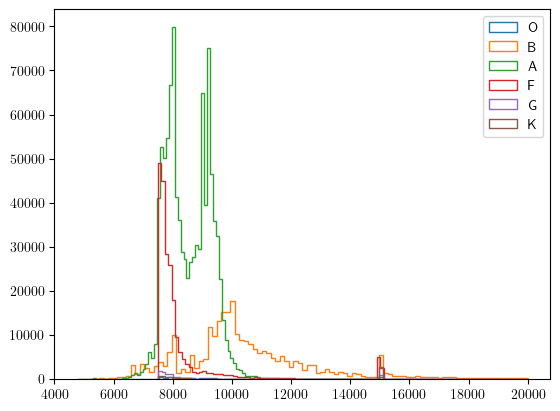

In [7]:
sptype = 'spectraltype_esphs'
df_astro[sptype].unique()
cols = ['source_id',sptype,'teff_gspphot']
df = df_source.merge(df_astro[cols],left_on='source_id',right_on='source_id',suffixes=['',''])
idx = df['teff_gspphot']<= 20000
df = df[idx]
fig, ax = plt.subplots()
for spt in ['O','B','A','F','G','K']:
    idx = df[sptype] == spt
    sel = df[idx]
    ax.hist(sel['teff_gspphot'],histtype='step',bins=100,label=spt)
ax.legend()
#plot_camd_density(df[idx])

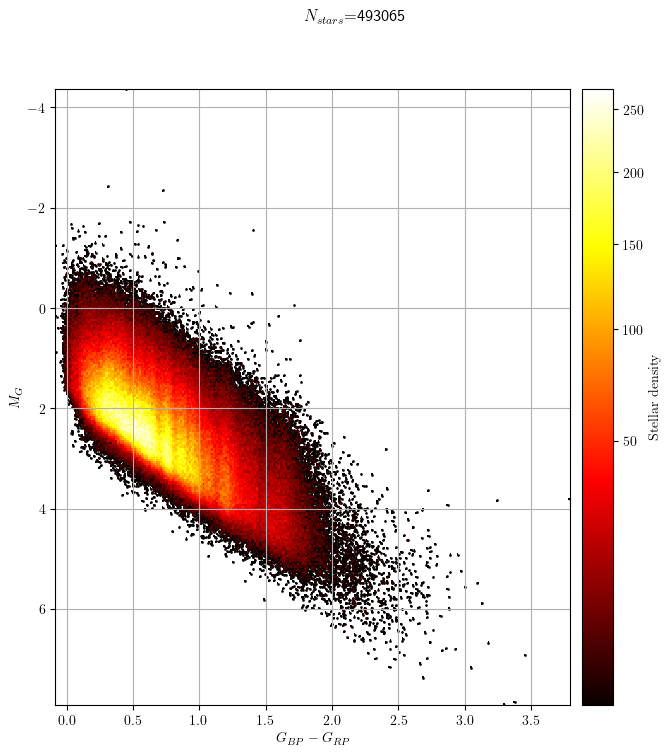

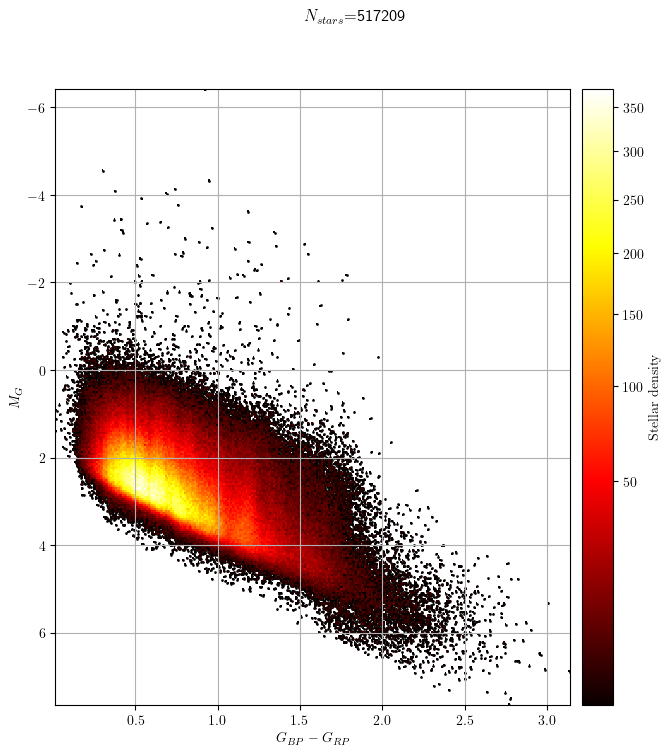

In [8]:
# select A stars
idx = df[sptype] == 'A'
selA = df[idx]
idxb = selA['teff_gspphot'] >= 8500
idxc = selA['teff_gspphot'] < 8500
plot_camd_density(selA[idxb])
plot_camd_density(selA[idxc])

In [9]:
selA.columns

Index(['source_id', 'ra', 'dec', 'pmra', 'pmdec', 'parallax', 'parallax_error',
       'phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'l', 'b',
       'phot_variable_flag', 'ref_epoch', 'L', 'B', 'ag_gspphot', 'MG',
       'bp_rp', 'MG_noext', 'spectraltype_esphs', 'teff_gspphot'],
      dtype='object')

In [10]:
#selA.to_hdf('A_stars.hdf5',key='stars')

In [11]:
idx = selA['phot_g_mean_mag'] >=6
idx = selA['phot_g_mean_mag'] <= 8
sselA = pd.DataFrame(selA[idx])
#sselA['sp_type'] = sselA['spectraltype_esphs']

ddf = pd.read_csv('/home/philippe/LSST/sn_pipe/ddf_ra_dec.csv')
width_RA=10
width_Dec = 10

dfb = pd.DataFrame()
for i, row in ddf.iterrows():
    RA_min = row['RA']-width_RA
    RA_max = row['RA']+width_RA
    Dec_min = row['Dec']-width_Dec
    Dec_max = row['Dec']+width_Dec
    idd = sselA['ra'] >= RA_min
    idd &= sselA['ra'] <= RA_max
    idd &= sselA['dec'] >= Dec_min
    idd &= sselA['dec'] <= Dec_max
    selb = sselA[idd]
    if len(selb) >= 1:
        dfb = pd.concat((dfb,selb))
print('alors',len(dfb))   
dfb.to_parquet('A_stars.parquet')

alors 132
